In [1]:
import pandas as pd
from ydata_profiling import ProfileReport
import getting_threshold_genes as gtg
from sklearn.model_selection import train_test_split
import model as m
import divide_bins as divide
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import optuna
from sklearn.metrics import accuracy_score
from sklearn.metrics import matthews_corrcoef
from ydata_profiling import ProfileReport
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
from catboost import CatBoostClassifier
import shap
import matplotlib.pyplot as plt
import numpy as np


2024-05-03 15:50:36.140463: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-05-03 15:50:36.142949: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-05-03 15:50:36.168035: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-03 15:50:36.168059: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-03 15:50:36.168672: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

# Compleate pipeline



## Data
We used reCombat for RNAseq and microarray independently one form another.

In [2]:
microRNA_orginal = pd.read_csv('Data/microarray_clean_reCombat.csv')
rnaSeq_origial =  pd.read_csv('Data/RNAseq_abundances_adjusted_recombat.csv')


In [3]:
seq_metadata_path = "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/All_rna_samples_metadata_edit.csv"
seq_metadata = pd.read_csv(seq_metadata_path)
rnaSeq_origial= pd.merge(rnaSeq_origial, seq_metadata, on='Sample', how='inner')
rnaSeq_origial

,Sample,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,...,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Experiment,Age,Status,Sex
0,SRR13388732,-0.013507,-0.008613,-0.015782,-0.012606,-0.012512,-0.007849,-0.009428,-0.005869,-0.016109,...,-0.007289,-0.008221,-0.008135,-0.007838,-0.001515,-0.009050,GSE164471,23.0,Healthy,male
1,SRR13388733,-0.020727,-0.036766,0.000817,-0.021617,-0.047792,-0.035041,0.016555,-0.029716,-0.023414,...,-0.036635,-0.035216,-0.035962,-0.035459,0.019047,-0.032990,GSE164471,28.0,Healthy,male
2,SRR13388734,-0.047985,-0.060597,0.019755,-0.059044,-0.034614,-0.066902,0.025750,-0.053573,-0.043942,...,-0.068829,-0.067163,-0.066478,-0.068147,-0.067372,-0.066392,GSE164471,31.0,Healthy,male
3,SRR13388735,0.007692,0.012561,0.004505,0.009135,0.004295,0.011404,-0.003279,0.002127,-0.014221,...,0.012388,0.011679,0.012378,0.012524,0.018481,0.013433,GSE164471,31.0,Healthy,male
4,SRR13388736,0.021639,-0.042779,-0.004353,-0.038308,-0.011563,-0.043566,-0.012129,0.037899,0.019374,...,-0.040471,-0.042044,-0.044774,-0.044207,-0.038909,-0.043675,GSE164471,35.0,Healthy,female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,SRR8882198,0.018746,0.028362,-0.000611,0.024016,0.017854,0.027669,0.003543,0.011436,0.004030,...,0.028305,0.027367,0.028665,0.028594,0.022648,0.028368,GSE129643,27.0,Healthy,female
266,SRR8882200,0.031651,0.038879,0.010388,0.035441,0.031588,0.037807,0.013077,0.024175,0.007002,...,0.038781,0.037155,0.038927,0.038838,0.032826,0.038477,GSE129643,33.0,Healthy,male
267,SRR8882202,0.024387,0.034184,0.012162,0.031678,0.023782,0.032860,0.013272,0.018142,0.009680,...,0.033751,0.032730,0.034059,0.034136,0.029831,0.033615,GSE129643,37.0,Healthy,male
268,SRR8882203,0.031462,0.040775,0.015024,0.038996,0.029837,0.039200,0.016456,0.023973,0.012532,...,0.040497,0.038967,0.040666,0.040694,0.036912,0.040364,GSE129643,38.0,Healthy,male


In [4]:
microRNA_profile = ProfileReport(microRNA_orginal, title="microRNA profiling report", minimal=True)
rnaSeq_profile = ProfileReport(rnaSeq_origial, title="RNAseq data profiling report", minimal=True)



In [5]:
#microRNA_profile.to_notebook_iframe()

We can see the distribution of the 

## Ridge regression for first filter

Prevously, I go the filtered genes for 

### Getting selected genes
Here I am using the ridge regression getting as threshold the genes that are higher that the second derivate of the approximated curve of the scores.
In feature_selection_all.ipnb, I ran the Ridge in all the data for both microRNA and RNAseq.
for example:
```dataset=all_microarray_data
result = get_feature_from_class(dataset)
result.to_csv("Results/feature_selection/microarray/ridge_L2_0/all_feature_selection.csv")
```


The ridge evaluation is collected here

In [6]:

rnaseq_path = f"Results/feature_selection/RNAseq/ridge_L2_0/Experiment_GSE167186_feature_selection_Symbols.csv"
microRNA_path = f"Results/feature_selection/microarray/ridge_L2_0/all_feature_selection_normalized.csv"



In [7]:
#gene_rank_df =gtg.get_gene_rank(microRNA_path)

In [8]:
#from kneed import KneeLocator
#kn = KneeLocator(gene_rank_df.index, gene_rank_df['abs_coef'], curve='convex', direction='decreasing')
#kn = KneeLocator(x, y, curve='convex', direction='decreasing')
#print(kn.knee)

In [9]:
#threshold = gene_rank_df['abs_coef'].sort_values().iloc[kn.elbow]

In [10]:
df = gtg.get_df(rnaseq_path)
rnaseq_genes = df["Ensembl"]
df = gtg.get_df(microRNA_path, inflexion=False)
microRNA_genes = df["Ensembl"]

0.03490092380136729
0.00922318416057


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gene_rank_df.iloc[0][1] == "coef":
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gene_rank_df.iloc[0][1] == "coef":


In [11]:
del df

In [12]:
print(f"Number of genes in RNAseq data: {len(rnaseq_genes)} \n Number of genes in microRNA data: {len(microRNA_genes)}")

Number of genes in RNAseq data: 1044 
 Number of genes in microRNA data: 112


So we got 241 genes for RNAseq and 112 for microRNA

### Filter by the genes

In [13]:
rnaseq_genes = rnaseq_genes.to_list()
microRNA_genes = microRNA_genes.to_list()
rnaseq_genes.append("Age")
rnaseq_genes.append("Experiment")
rnaseq_genes.append("Status")
rnaseq_genes.append("Sex")
microRNA_genes.append("Age")
microRNA_genes.append("Experiment")
rnaSeq_filteres = rnaSeq_origial[rnaseq_genes]
microRNA_filtered = microRNA_orginal[microRNA_genes]


In [85]:
microRNA_filtered.shape

(522, 114)

In [84]:
rnaSeq_filteres["Experiment"].value_counts()

Experiment
GSE157585    84
GSE167186    75
GSE164471    46
GSE60590     31
GSE129643    29
GSE152558     5
Name: count, dtype: int64

### Separate test and train datasets

Here I will use prefix seq to say RNAse and arr to say microarray. I am using a test_size of 50 because I will use smote to increase the data for the training.

In [15]:
seq_X_train, seq_X_test, seq_y_train, seq_y_test, seq_z_train, seq_z_test = m.divide_test_train_dataset(rnaSeq_filteres, test_size=0.3)
arr_X_train, arr_X_test, arr_y_train, arr_y_test, arr_z_train, arr_z_test = m.divide_test_train_dataset(microRNA_filtered, test_size=0.3)


### Divide the ages into bins

For microRNA, I found the best bins to be
[18, 31, 41, 47,  54, 64, 90]

```
[{'label': '18-31', 'range': (18, 31.0), 'count': 44},
 {'label': '31-41', 'range': (31.0, 41.0), 'count': 46},
 {'label': '41-47', 'range': (41.0, 47.04), 'count': 40},
 {'label': '47-54', 'range': (47.04, 54.0), 'count': 46},
 {'label': '54-64', 'range': (54.0, 64.02), 'count': 40},
 {'label': '64-90', 'range': (64.02, 90), 'count': 44}]
 ```
 
And for RNAseq
[18, 25, 35, 45,70,72,  90]
```
[{'label': '18-25', 'range': (18, 25), 'count': 22},
 {'label': '25-35', 'range': (25, 35), 'count': 23},
 {'label': '35-45', 'range': (35, 45), 'count': 9},
 {'label': '45-70', 'range': (45, 70), 'count': 19},
 {'label': '70-72', 'range': (70, 72), 'count': 41},
 {'label': '72-90', 'range': (72, 90), 'count': 21}]
```
This was a semi manual twick to find the best combination on 

arr_age_ranges = divide.get_age_distribution(arr_y_train, q_ranges=[100/6, 200/6, 300/6, 400/6, 500/6])
seq_age_ranges = divide.get_age_distribution(seq_y_train, age_ranges=[18, 25, 35, 45,70,72,  90])

Where we look to have a balanced set and still cover as best as possible the <35,65< limits. 
 

In [16]:
arr_age_ranges = divide.get_age_distribution(arr_y_train, q_ranges=[100/6, 200/6, 300/6, 400/6, 500/6])
seq_age_ranges = divide.get_age_distribution(seq_y_train, age_ranges=[17, 25, 35, 45,70,72,  100])


[30.76333333 41.         47.46       53.66666667 64.01      ]


In [17]:
arr_categories= [18, 31, 41, 47,  54, 64, 90]
seq_categories = [18, 25, 35, 45, 70, 72, 90]

# Function to find the closest category value
#def find_closest_category(value, categories):
#    return min(categories, key=lambda x: abs(x - value))



In [18]:
#arr_df = pd.DataFrame(arr_X_train)
#seq_df = pd.DataFrame(seq_X_train)
#arr_df["Age"] = arr_y_train
#seq_df["Age"] = seq_y_train
#arr_df

In [19]:
arr_y_train_cat = arr_y_train.apply(lambda x: divide.assign_age_group(x, arr_age_ranges))
seq_y_train_cat = seq_y_train.apply(lambda x: divide.assign_age_group(x, seq_age_ranges))

In [20]:
#ProfileReport(pd.DataFrame(seq_y_train_cat), minimal=False).to_notebook_iframe() 

### Balanced the data using smote

In [21]:
dataset = pd.DataFrame(arr_X_train)
dataset["Age"] = arr_y_train_cat
result = divide.get_feature_SMOTE(dataset, is_categorical=True)
arr_X_train_cat_a = pd.DataFrame(result[0])
arr_y_train_cat_a = result[1]

Class distribution before SMOTE: Counter({'41-47': 66, '64-90': 61, '53-64': 61, '47-53': 61, '18-30': 61, '30-41': 55})
Class distribution after SMOTE: Counter({'64-90': 66, '53-64': 66, '30-41': 66, '41-47': 66, '47-53': 66, '18-30': 66})


In [22]:
dataset = pd.DataFrame(seq_X_train)
dataset["Age"] = seq_y_train_cat
result = divide.get_feature_SMOTE(dataset, is_categorical=True)
seq_X_train_cat_a = pd.DataFrame(result[0])
seq_y_train_cat_a = result[1]

Class distribution before SMOTE: Counter({'70-72': 52, '25-35': 35, '72-100': 33, '45-70': 29, '17-25': 29, '35-45': 11})
Class distribution after SMOTE: Counter({'70-72': 52, '25-35': 52, '72-100': 52, '35-45': 52, '45-70': 52, '17-25': 52})


In [23]:
dataset[dataset["Age"]=="Unknown"]

,ENSG00000185915.5,ENSG00000276045.3,ENSG00000171055.14,ENSG00000177508.11,ENSG00000257542.5,ENSG00000111605.16,ENSG00000153130.17,ENSG00000153179.12,ENSG00000168763.15,ENSG00000101892.11,...,ENSG00000185641.6,ENSG00000085982.13,ENSG00000147669.10,ENSG00000225471.5,ENSG00000076685.18,ENSG00000085719.12,ENSG00000180209.11,ENSG00000108826.15,ENSG00000184182.18,Age


#### Add noise to the data

In [24]:
noise = np.random.normal(0.01, 0.01, arr_X_train_cat_a.shape)  # Generate random noise with mean 0 and standard deviation 1
#arr_X_train_cat_a = arr_X_train_cat_a + noise
 # Generate random noise with mean 0 and standard deviation 1



In [25]:

arr_y_train_a = pd.Series(arr_y_train_cat_a).str.split('-')
arr_y_train_a = arr_y_train_a.apply(lambda x: (int(x[0]) + int(x[1])) / 2)



In [26]:
y_noise = np.random.normal(0, 2, arr_y_train_a.shape)
arr_y_train_a = arr_y_train_a + y_noise
arr_y_train_a = arr_y_train_a.round(0)

In [27]:
noise = np.random.normal(0.01, 0.01, seq_X_train_cat_a.shape)  # Generate random noise with mean 0 and standard deviation 1
#seq_X_train_cat_a = seq_X_train_cat_a + noise


In [28]:

seq_y_train_a = pd.Series(seq_y_train_cat_a).str.split('-')
seq_y_train_a = seq_y_train_a.apply(lambda x: (int(x[0]) + int(x[1])) / 2)

y_noise = np.random.normal(0, 2, seq_y_train_a.shape)
seq_y_train_a = seq_y_train_a + y_noise
seq_y_train_a = seq_y_train_a.round(0)


Now, we have for microarray and rna seq, an augmented training dataset.

### Normalizing the data

First we take a look on the data. And proceed with the normalization.
NOTE: I have to re run the RIdge (Maybe) because this step should be before

In [29]:
# normalize the data z score
arr_normalize_X_train, arr_scaler = m.normalize_train_data(arr_X_train_cat_a)
seq_normalize_X_train, seq_scaler = m.normalize_train_data(seq_X_train_cat_a)

### Preparing the model

Before running the model, we look for the best parameter

First we define the optimization function like the following

In [30]:
class optimize:
    def __init__(self,train_data, n_trials=50):
        X_train, X_test, y_train, y_test, _, _ = m.divide_test_train_dataset(train_data, test_size=0.2)
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        self.n_trials = n_trials
    def optimize(self):
        study = optuna.create_study(direction='minimize')  # Maximize accuracy
        study.optimize(self.objective, n_trials=self.n_trials) 
    def objective(self, trial):
        # Define hyperparameters to optimize
        params = {
            'iterations': trial.suggest_int('iterations', 50, 1000),
            'learning_rate': trial.suggest_loguniform('learning_rate', 0.001, 0.01),
            'depth': trial.suggest_int('depth', 2, 5),
            'random_state': 42,  # Fixed random state
            'verbose': 0,  # Fixed verbosity
            'od_type': 'Iter',  # Early stopping type
            'od_wait': 5,  # Early stopping patience
            #'eval_metric': 'RMSE'  # Metric to optimize

        }
        params = {
        'iterations': trial.suggest_int('iterations', 50, 100),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.001, 0.01),
        'depth': trial.suggest_int('depth', 2, 5),  # Modify depth range to match the original
        'verbose': 0,  # Fixed verbosity
        'od_type': 'Iter',  # Early stopping type
        'od_wait': 5,  # Early stopping patience
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.0, 10.0),  # L2 regularization coefficient
        #'sampling_frequency': trial.suggest_categorical('sampling_frequency', ['PerTree', 'PerTreeLevel', 'PerTreeNode']),  # Frequency of sampling
        'random_strength': trial.suggest_float('random_strength', 0.0, 10.0),  # Random strength
        #'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide']),  # Tree growth policy
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),  # Minimum number of samples in leaf
        #'boosting_type': trial.suggest_categorical('boosting_type', ['Ordered', 'Plain']),  # Type of boosting
        'score_function': trial.suggest_categorical('score_function', ['Cosine', 'L2']),  # Metric to use
        'penalties_coefficient': trial.suggest_float('penalties_coefficient', 0.0, 10.0),  # Penalty coefficient
        'model_shrink_rate': trial.suggest_float('model_shrink_rate', 0.0, 1.0),  # Model shrink rate
        #'model_shrink_mode': trial.suggest_categorical('model_shrink_mode', ['Constant', 'ShrinkToBest', 'ShrinkToRandom']),  # Model shrink mode
        'eval_metric': 'RMSE'  # Metric to optimize
    }

        # Initialize classifier with the suggested hyperparameters
        regressor = CatBoostRegressor(**params)

        # Fit the model
        regressor.fit(self.X_train, self.y_train, eval_set=(self.X_test, self.y_test), use_best_model=True)
        # Make predictions
        y_pred = regressor.predict(self.X_test)
        # Calculate auc
        auc = mean_squared_error(self.y_test, y_pred)
        return auc


In [31]:
#dataset = pd.DataFrame(arr_normalize_X_train)
#dataset.columns = arr_X_train_cat_a.columns
#dataset["Age"] = arr_y_train_cat_a
##dataset['Age'] = dataset['Age'].str.split('-')
#dataset['Age'] = dataset['Age'].apply(lambda x: (int(x[0]) + int(x[1])) / 2)
#arr_optimize = optimize(train_data = dataset, n_trials=20)
#arr_params = arr_optimize.optimize()
#arr_params

In [32]:
arr_params =  {'iterations': 557, 'learning_rate': 0.006870852326814436, 'depth': 2, 'l2_leaf_reg': 3.376311004531222, 'random_strength': 8, 'min_data_in_leaf': 56, 'score_function': 'L2', 'penalties_coefficient': 8, 'model_shrink_rate': 0.0007591018056407467}

And run it like this:
```
dataset = pd.DataFrame(arr_normalize_X_train)
dataset.columns = arr_X_train_cat_a.columns
dataset["Age"] = arr_y_train_cat_a
dataset['Age'] = dataset['Age'].str.split('-')
dataset['Age'] = dataset['Age'].apply(lambda x: (int(x[0]) + int(x[1])) / 2)
arr_optimize = optimize(train_data = dataset, n_trials=150)
arr_params = arr_optimize.optimize()
arr_params
```
There is no good reason to run it again here, since it is to Tweak the parameters. 


In [33]:
arr_parms =  {'iterations': 64, 'learning_rate': 0.0012, 'depth': 15}
seq_parms = {'iterations': 462, 'learning_rate': 0.0510, 'depth': 5}



### Train the model
For this, we will take catBoost since is the one that worked the best

#### microarray

Now we are ready to train the arr_normalize_X_train that is the microarray test half of the data, filtered by the genes from Ridge, normalized, augmented.
We will only use the training section for this part. 

In [79]:
dataset = pd.DataFrame(arr_normalize_X_train)
dataset.columns = microRNA_genes[:-2]
dataset["Age"] = arr_y_train_a
#dataset["Experiment"] = arr_z_train

X_train, X_test, y_train, y_test, z_train, z_test = m.divide_test_train_dataset(dataset, test_size=0.3)

"""
# Initialize CatBoostClassifier
#arr_regressor = CatBoostClassifier(iterations=1500,  # Number of boosting iterations
                              learning_rate=0.0001,  # Learning rate
                              depth=5,  # Depth of trees
                              random_state=5,  # Random seed for reproducibility
                              verbose= 1,  # Verbosity level (0 - silent, 1 - verbose)
                              od_type= 'Iter',  # Early stopping type
                              od_wait= 100,  # Early stopping patience
                              #l2_leaf_reg= 56,  # L2 regularization coefficient
                              sampling_frequency = 'PerTreeLevel',  # Frequency of sampling
                              random_strength = 7,  # Random strength
                              #grow_policy = 'Depthwise',  # Tree growth policy
                              min_data_in_leaf = 1,  # Minimum number of samples in leaf
                              #boosting_type = 'Plain',  # Type of boosting
                              #score_function = 'L2',  # Metric to use
                              penalties_coefficient = 5,  # Penalty coefficient
                              model_shrink_rate = 0.1,  # Model shrink rate
                              model_shrink_mode = 'Constant',  # Model shrink mode
                              eval_metric = 'MCC'  # Metric to optimize
                              )
                            
#arr_regressor = CatBoostRegressor(**arr_params)
"""
# Fit the model
#arr_regressor.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True, plot=True)



"\n# Initialize CatBoostClassifier\n#arr_regressor = CatBoostClassifier(iterations=1500,  # Number of boosting iterations\n                              learning_rate=0.0001,  # Learning rate\n                              depth=5,  # Depth of trees\n                              random_state=5,  # Random seed for reproducibility\n                              verbose= 1,  # Verbosity level (0 - silent, 1 - verbose)\n                              od_type= 'Iter',  # Early stopping type\n                              od_wait= 100,  # Early stopping patience\n                              #l2_leaf_reg= 56,  # L2 regularization coefficient\n                              sampling_frequency = 'PerTreeLevel',  # Frequency of sampling\n                              random_strength = 7,  # Random strength\n                              #grow_policy = 'Depthwise',  # Tree growth policy\n                              min_data_in_leaf = 1,  # Minimum number of samples in leaf\n                   

In [80]:
z_test

,Age
134,50.0
209,73.0
133,50.0
342,26.0
15,45.0
...,...
73,20.0
9,60.0
130,76.0
328,56.0


In [35]:
arr_params

{'iterations': 557,
 'learning_rate': 0.006870852326814436,
 'depth': 2,
 'l2_leaf_reg': 3.376311004531222,
 'random_strength': 8,
 'min_data_in_leaf': 56,
 'score_function': 'L2',
 'penalties_coefficient': 8,
 'model_shrink_rate': 0.0007591018056407467}

In [63]:


# Initialize CatBoostClassifier
arr_regressor = CatBoostRegressor(iterations=500,  # Number of boosting iterations
                              learning_rate=0.01,  # Learning rate
                              depth=4,  # Depth of trees
                              random_state=42,  # Random seed for reproducibility
                              verbose= 0,  # Verbosity level (0 - silent, 1 - verbose)
                              od_type= 'Iter',  # Early stopping type
                              od_wait= 50,  # Early stopping patience

                            )  

# Fit the model
arr_regressor.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True, plot=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [53]:
#ProfileReport(pd.DataFrame(y_train), title="y train profiling report", minimal=True).to_notebook_iframe()

In [64]:
# Make predictions
y_pred = arr_regressor.predict(X_test)

# Evaluate mean squared error
arr_mse = mean_squared_error(y_test, y_pred)
arr_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})


In [ ]:
arr_results

In [81]:
from sklearn.metrics import roc_auc_score

# Convert actual and predicted values into binary labels
y_true = arr_results['Actual'].apply(lambda x: 1 if x >= 50 else 0)
y_pred = arr_results['Predicted'].apply(lambda x: 1 if x >= 50 else 0)

# Calculate the AUC
auc = roc_auc_score(y_true, y_pred)
auc


0.735042735042735

/tmp/ipykernel_583227/1562571159.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Actual', y='Predicted', data=arr_results, palette='Set1', alpha=0.8, edgecolor='w')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


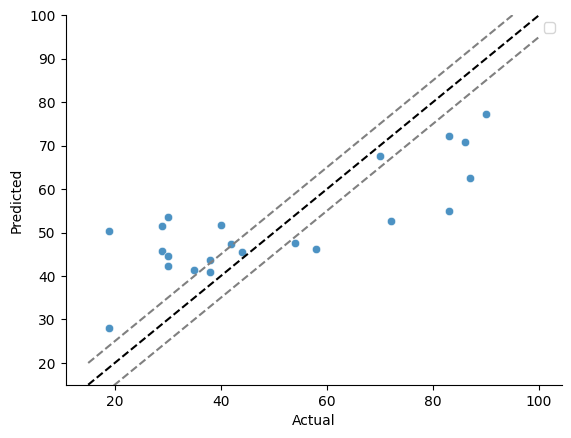

In [66]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=arr_results, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

In [67]:
c_y_test = pd.Series(y_test).apply(lambda x: divide.assign_age_group(x, arr_age_ranges))
c_y_pred = pd.Series(y_pred).apply(lambda x: divide.assign_age_group(x, arr_age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[1, 0, 3, 3, 0, 0, 0],
       [0, 1, 2, 1, 0, 0, 0],
       [0, 0, 2, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 1, 0, 0, 0],
       [0, 0, 0, 1, 2, 3, 0],
       [0, 0, 0, 0, 0, 1, 0]])

In [68]:
arr_age_ranges

[{'label': '18-30', 'range': (18, 30.763333333333335), 'count': 60},
 {'label': '30-41', 'range': (30.763333333333335, 41.0), 'count': 63},
 {'label': '41-47', 'range': (41.0, 47.46), 'count': 59},
 {'label': '47-53', 'range': (47.46, 53.666666666666686), 'count': 60},
 {'label': '53-64', 'range': (53.666666666666686, 64.01), 'count': 61},
 {'label': '64-90', 'range': (64.01, 90), 'count': 61}]

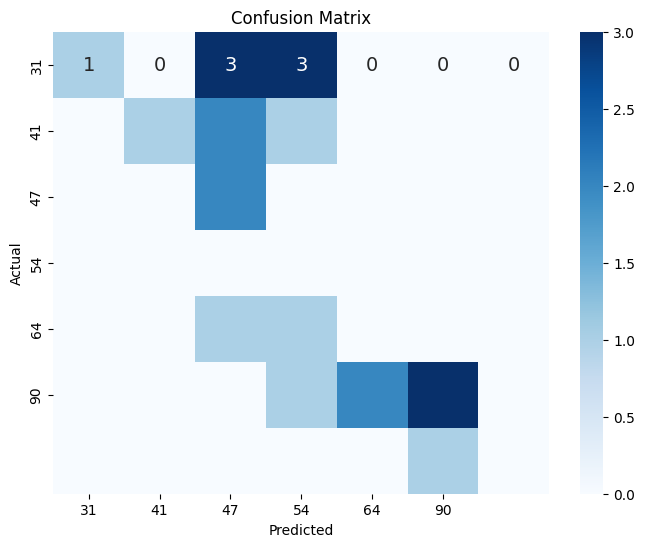

In [69]:

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(arr_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=arr_categories[1:], yticklabels=arr_categories[1:], fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [70]:
arr_normalize_X_test = arr_scaler.transform(arr_X_test)
arr_normalize_X_test
len(arr_normalize_X_test)
arr_y_test

189    54.00
446    76.09
305    56.00
80     27.65
391    53.50
       ...  
160    47.00
112    28.00
38     70.00
370    23.00
335    41.00
Name: Age, Length: 157, dtype: float64

In [74]:
arr_normalize_X_test= pd.DataFrame(arr_normalize_X_test, columns=arr_X_test.columns)
arr_normalize_X_test

,AW138371,W52819,BG911806,AW291521,AK093727,AI094580,BF511588,AK022235,AV702787,AA393940,...,AJ012500,BE966604,AV724266,AI802325,AK093266,AI656867,S75174,NM_004451,AV738806,NM_002612
0,-0.025114,0.394559,-0.824990,-0.590791,-0.235942,-0.723469,-0.603331,0.184393,0.215588,1.680100,...,-0.022265,-0.409377,-1.027547,-0.265955,-0.311883,-0.039189,-0.663288,-1.120542,-0.099528,-0.114702
1,-0.064412,0.419815,-0.577985,-0.047989,-0.806796,0.402941,-0.664796,0.615068,-1.324191,1.080638,...,-0.636931,-0.839477,-1.216013,-0.022730,0.409872,-0.148995,0.012267,0.009322,-0.597251,-0.231997
2,1.366754,1.617723,0.422743,-0.054343,0.158950,0.347174,-0.314891,0.289056,0.325443,-0.081907,...,-0.185714,-0.494241,-0.476133,-0.112812,-0.195550,-0.463696,-0.212115,0.028695,1.467637,-0.223033
3,0.585760,0.902291,1.167811,-1.057032,0.203651,-0.011178,-0.939245,-0.105100,0.189094,-0.887138,...,-0.173550,0.838258,1.973276,-0.630686,-0.295474,0.221552,-0.241532,-0.058553,0.739344,0.357735
4,-0.027343,-0.066184,0.721376,-0.032016,-0.046332,-0.060985,0.337995,0.050472,-0.089213,-0.073724,...,0.704921,0.113531,0.024222,0.005633,-0.674829,0.049007,0.021503,-0.355564,0.010546,0.388304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,1.114743,-0.969288,1.832250,1.070662,0.901156,2.948354,1.217097,4.138540,-0.174115,-0.902405,...,1.230088,0.077623,-1.756090,1.217450,1.547207,2.192604,2.510324,0.774018,0.763797,-1.611306
153,0.562048,-2.017741,0.311785,1.522744,0.142615,-0.011556,0.784315,-0.114419,-0.853201,0.740925,...,-0.016135,-1.097528,-0.574713,-0.463441,1.133312,0.936710,1.415708,1.433555,0.010879,0.850554
154,0.245386,0.394454,-0.289155,0.412457,-0.502298,0.040530,-1.180417,0.507745,-0.373501,0.176575,...,0.147501,0.598480,0.283332,0.560408,-2.313382,0.606173,0.315175,-0.557995,0.265069,0.405779
155,0.151778,1.179616,1.144829,1.006636,0.699989,1.751244,1.554225,1.462477,-1.706184,2.345167,...,0.080824,-0.144093,-0.071071,0.651218,1.390155,1.542104,1.042793,0.002393,0.452093,-0.762539


In [71]:
arr_y_test_c = pd.Series(arr_y_test).apply(lambda x: divide.assign_age_group(x, arr_age_ranges))
arr_y_test_c = pd.Series(arr_y_test_c).str.split('-')
arr_y_test_c = arr_y_test_c.apply(lambda x: (int(x[0]) + int(x[1])) / 2)
arr_y_test_c

189    58.5
446    77.0
305    58.5
80     24.0
391    50.0
       ... 
160    44.0
112    24.0
38     77.0
370    24.0
335    44.0
Name: Age, Length: 157, dtype: float64

In [75]:
y_pred = arr_regressor.predict(arr_normalize_X_test)

# Evaluate mean squared error
arr_mse = mean_squared_error(arr_y_test_c, y_pred)
arr_results = pd.DataFrame({'Actual': arr_y_test_c, 'Predicted': y_pred})

CatBoostError: /src/catboost/catboost/libs/data/model_dataset_compatibility.cpp:81: At position 0 should be feature with name ENSG00000185915.5 (found AW138371).

In [ ]:
c_y_test = arr_results["Actual"].apply(lambda x: divide.assign_age_group(x, arr_age_ranges))
c_y_pred = arr_results["Predicted"].apply(lambda x: divide.assign_age_group(x, arr_age_ranges))
arr_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
arr_confusion_matrix

array([[ 0,  0, 11, 20,  0,  0],
       [ 0,  0,  4,  9,  0,  0],
       [ 0,  0, 12, 20,  0,  0],
       [ 0,  0,  2, 20,  0,  0],
       [ 0,  0,  3, 30,  0,  0],
       [ 0,  0,  3, 23,  0,  0]])

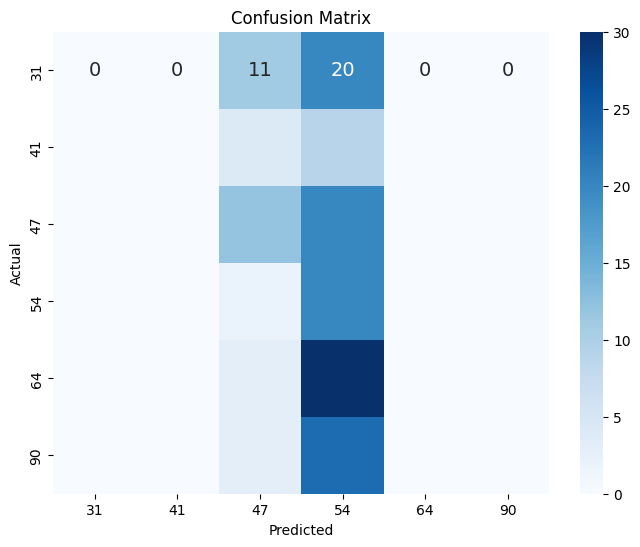

In [ ]:
# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(arr_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=arr_categories[1:], yticklabels=arr_categories[1:], fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
arr_test_df = pd.DataFrame(arr_normalize_X_test)
arr_test_df.columns = arr_X_train_cat_a.columns
arr_test_df["Age"]= arr_y_test_c

In [ ]:
explainer = shap.Explainer(arr_regressor)
shap_values = explainer.shap_values(arr_test_df)
importance = arr_regressor.get_feature_importance()
feature_imporance_df = pd.DataFrame(importance, index=arr_X_train_cat_a.columns, columns=["importance"])
feature_imporance_df=feature_imporance_df[feature_imporance_df["importance"] > 0]
feature_imporance_df = feature_imporance_df.sort_values(by="importance", ascending=False)
feature_imporance_df

,importance
NM_002472,9.675474
AI214944,8.876258
U20489,5.127235
NM_004451,4.823809
M36769,4.138789
...,...
AJ296370,0.102157
AA025858,0.100654
AK096937,0.070815
NM_022146,0.062905


In [ ]:
feature_imporance_df.head(20)

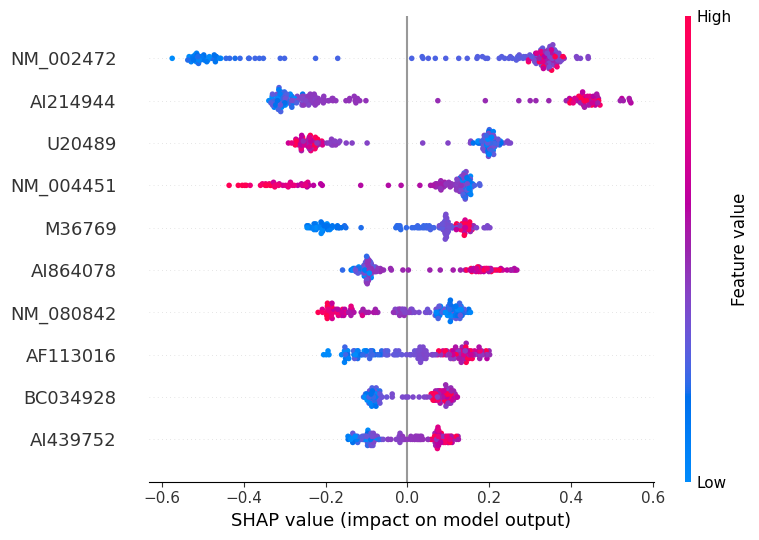

In [ ]:

shap.summary_plot(shap_values, arr_test_df, max_display=10)


#### RNAseq


In [ ]:
dataset = pd.DataFrame(seq_normalize_X_train)
dataset.columns = seq_X_train_cat_a.columns
dataset["Age"] = seq_y_train_a


#dataset = pd.DataFrame(seq_X_train)
#dataset.columns = rnaseq_genes[:-2]
#dataset["Age"] = seq_y_train

X_train, X_test, y_train, y_test, _, _ = m.divide_test_train_dataset(dataset, test_size=0.07)


# Initialize CatBoostClassifier
seq_regressor = CatBoostRegressor(iterations=4000,
                                  learning_rate=0.005,
                                  depth=3,
                                  random_state=42,
                                  verbose=1,
                                  od_type='Iter',
                                  od_wait=50,
                                  penalties_coefficient=50,
                                  l2_leaf_reg=5,  # Adjust regularization
                                  ) 

# Fit the model



MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 22.8177754	test: 23.4790298	best: 23.4790298 (0)	total: 12.6ms	remaining: 50.2s
1:	learn: 22.7843792	test: 23.4611916	best: 23.4611916 (1)	total: 22.5ms	remaining: 45.1s
2:	learn: 22.7477909	test: 23.4288178	best: 23.4288178 (2)	total: 32.6ms	remaining: 43.4s
3:	learn: 22.7113899	test: 23.3869649	best: 23.3869649 (3)	total: 44.9ms	remaining: 44.9s
4:	learn: 22.6780679	test: 23.3924049	best: 23.3869649 (3)	total: 58.3ms	remaining: 46.6s
5:	learn: 22.6424732	test: 23.3740555	best: 23.3740555 (5)	total: 74.8ms	remaining: 49.8s
6:	learn: 22.6209378	test: 23.3607001	best: 23.3607001 (6)	total: 84.9ms	remaining: 48.4s
7:	learn: 22.5918163	test: 23.3539409	best: 23.3539409 (7)	total: 96.1ms	remaining: 47.9s
8:	learn: 22.5657810	test: 23.3405027	best: 23.3405027 (8)	total: 108ms	remaining: 47.7s
9:	learn: 22.5348970	test: 23.3090005	best: 23.3090005 (9)	total: 117ms	remaining: 46.8s
10:	learn: 22.5064467	test: 23.3013065	best: 23.3013065 (10)	total: 128ms	remaining: 46.5s
11:	learn: 

KeyboardInterrupt: 

In [ ]:
# Make predictions
y_pred = seq_regressor.predict(X_test)

# Evaluate mean squared error
seq_mse = mean_squared_error(y_test, y_pred)
seq_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
seq_mse


#### Plotting results

We have some pre desing plots for the results.

In [ ]:
seq_results["Actual_round"] = seq_results["Actual"].apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
seq_results["Predicted_round"] = seq_results["Predicted"].apply(lambda x: divide.assign_age_group(x, seq_age_ranges))

In [ ]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

#### Reviewing with original (not augmented) data

In [ ]:
seq_X_train_normalize = seq_scaler.transform(seq_X_train)
y_pred = seq_regressor.predict(seq_X_train_normalize)
seq_mse = mean_squared_error(seq_y_train, y_pred)
seq_mse


In [ ]:

seq_results = pd.DataFrame({'Actual': seq_y_train, 'Predicted': y_pred})
seq_results["Actual_round"] = seq_results["Actual"].apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
seq_results["Predicted_round"] = seq_results["Predicted"].apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
m.plot_results(results=seq_results, labels=seq_z_train)

#### Reviewing with compleatly untouch data

In [ ]:
seq_normalize_X_test = seq_scaler.transform(seq_X_test)

print(len(seq_normalize_X_test))

In [ ]:
y_pred = seq_regressor.predict(seq_normalize_X_test)
len(y_pred)

In [ ]:

# Evaluate mean squared error
seq_mse = mean_squared_error(seq_y_test, y_pred)
seq_mse

In [ ]:
seq_results = pd.DataFrame({'Actual': seq_y_test, 'Predicted': y_pred})
seq_results["Actual_round"] = seq_results["Actual"].apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
seq_results["Predicted_round"] = seq_results["Predicted"].apply(lambda x: divide.assign_age_group(x, seq_age_ranges))



In [ ]:
seq_z_test

In [ ]:
m.plot_results(results=seq_results, labels=seq_z_test)

In [ ]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

### Feaures

In [ ]:
explainer = shap.Explainer(seq_regressor)
seq_test_df = pd.DataFrame(seq_normalize_X_test)
seq_test_df.columns = seq_X_train_cat_a.columns
seq_test_df["Age"]= seq_y_test
shap_values = explainer.shap_values(seq_test_df)
importance = seq_regressor.get_feature_importance()
feature_imporance_df = pd.DataFrame(importance, index=seq_X_train_cat_a.columns, columns=["importance"])
feature_imporance_df=feature_imporance_df[feature_imporance_df["importance"] > 0]
feature_imporance_df = feature_imporance_df.sort_values(by="importance", ascending=False)
feature_imporance_df

In [ ]:
feature_imporance_df[:30]

In [ ]:
shap.summary_plot(shap_values, seq_test_df, max_display=10)


In [ ]:
feature_imporance_df.to_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/feature_selection/RNAseq_shap_2.csv", index=True)

# Double filter


In [ ]:
filter_genes = feature_imporance_df[feature_imporance_df["importance"] > 0.1].index
filter_genes = filter_genes.to_list()
len(filter_genes)


In [ ]:
dataset[dataset["Age"]=="Unknown"] 

In [ ]:
seq_age_ranges

In [ ]:
dataset = pd.DataFrame(seq_normalize_X_train)
dataset.columns = seq_X_train_cat_a.columns
dataset = dataset[filter_genes]
dataset["Age"] = seq_y_train_a


#dataset = pd.DataFrame(seq_X_train)
#dataset.columns = rnaseq_genes[:-2]
#dataset["Age"] = seq_y_train

X_train, X_test, y_train, y_test, _, _ = m.divide_test_train_dataset(dataset, test_size=0.07)

y_train = pd.Series(y_train).apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
y_test = pd.Series(y_test).apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
# Initialize CatBoostClassifier
seq_classifier = CatBoostClassifier(iterations=4000,
                                  learning_rate=0.005,
                                  depth=3,
                                  random_state=42,
                                  verbose=1,
                                  od_type='Iter',
                                  od_wait=50,
                                  penalties_coefficient=50,
                                  l2_leaf_reg=5,  # Adjust regularization
                                  #eval_metric='MCC'  # Metric to optimize
                                  ) 

# Fit the model
seq_classifier.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True, plot=True)



In [ ]:
y_pred = seq_classifier.predict(X_test)

# Evaluate mean squared error
seq_mcc = matthews_corrcoef(y_test, y_pred)
seq_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred.T[0]})
seq_mcc

In [ ]:
c_y_test = seq_results["Actual"]#.apply(lambda x: divide.assign_age_group(x, arr_age_ranges))
c_y_pred = seq_results["Predicted"]#.apply(lambda x: divide.assign_age_group(x, arr_age_ranges))
seq_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
seq_confusion_matrix

In [ ]:
# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(seq_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=seq_categories[1:], yticklabels=seq_categories[1:], fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
seq_X_train_normalize = seq_scaler.transform(seq_X_train)

seq_normalize_X_test_filter = pd.DataFrame(seq_X_train_normalize)
seq_normalize_X_test_filter.columns = rnaseq_genes[:-4]


Source data

 I WAS HERE!!!!!!!!!!!!!!!!!!!!
 The mcc of the source data make no sense, find the error

In [ ]:
seq_normalize_X_test_filter= seq_normalize_X_test_filter[filter_genes]


In [ ]:
y_pred = seq_classifier.predict(seq_normalize_X_test_filter)

In [ ]:
X_test.shape

In [ ]:
len(y_pred.T[0])

In [ ]:


seq_results = pd.DataFrame({'Actual': seq_y_train, 'Predicted': y_pred.T[0]})
seq_y_test_c = pd.Series(seq_y_train).apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
seq_mcc = matthews_corrcoef(seq_y_test_c, y_pred.T[0])
seq_mcc

In [ ]:
seq_results

In [ ]:
seq_results_return = seq_results.copy()
seq_results_return["Predicted"] = seq_results_return["Predicted"].str.split('-')
seq_results_return["Predicted"] = seq_results_return["Predicted"].apply(lambda x: (int(x[0]) + int(x[1])) / 2)
noise = np.random.normal(2, 2, len(seq_results_return))
seq_results_return["Predicted"] = seq_results_return["Predicted"] + noise



In [ ]:
m.plot_results(results=seq_results_return, labels=seq_z_train)

In [ ]:
m.plot_results(results=seq_results_return, labels=seq_z_train, print_label="Status")

_______________________________________________________________________________________________________________________________

Unseen data

In [ ]:
# Make predictions
X_test_filter = pd.DataFrame(seq_X_test)
X_test_filter.columns = rnaseq_genes[:-4]
X_test_filter = seq_scaler.transform(X_test_filter)
X_test_filter = pd.DataFrame(X_test_filter)
X_test_filter.columns = rnaseq_genes[:-4]
X_test_filter = X_test_filter[filter_genes]


In [ ]:
#normalize_seq_X_test = seq_scaler.transform(seq_X_test)
y_pred = seq_classifier.predict(X_test_filter)
seq_y_test_c = pd.Series(seq_y_test).apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
# Evaluate mean squared error
seq_mcc = matthews_corrcoef(seq_y_test_c, y_pred)
seq_results = pd.DataFrame({'Actual': seq_y_test_c, 'Predicted': y_pred.T[0]})
seq_mcc

In [ ]:
c_y_test = seq_results["Actual"]#.apply(lambda x: divide.assign_age_group(x, arr_age_ranges))
c_y_pred = seq_results["Predicted"]#.apply(lambda x: divide.assign_age_group(x, arr_age_ranges))
seq_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
seq_confusion_matrix

In [ ]:

# Evaluate mean squared error
# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(seq_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=seq_categories[1:], yticklabels=seq_categories[1:], fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
seq_results_return = seq_results.copy()
seq_results_return["Actual"]  = seq_y_test
seq_results_return["Predicted"] = seq_results_return["Predicted"].str.split('-')
seq_results_return["Predicted"] = seq_results_return["Predicted"].apply(lambda x: (int(x[0]) + int(x[1])) / 2)
noise = np.random.normal(2, 2, len(seq_results_return))
seq_results_return["Predicted"] = seq_results_return["Predicted"] + noise
m.plot_results(results=seq_results_return, labels=seq_z_test)

In [ ]:
m.plot_results(results=seq_results_return, labels=seq_z_test, print_label="Status")

In [ ]:
m.plot_results(results=seq_results_return, labels=seq_z_test, print_label="Sex")

### Only those that are sure

In [ ]:
y_pred_prod = seq_classifier.predict_proba(X_test_filter)

y_prod_df = pd.DataFrame(y_pred_prod)
# get the max column value or 0.6
y_prod_df

In [ ]:
threshold = 0.4
max_values = y_prod_df.apply(lambda row: row[row > threshold].idxmax() if (row > threshold).any() else "Unk", axis=1)
max_values
seq_results['cat'] = seq_results['Actual'].astype('category').cat.codes
seq_results["Class"]= max_values.values
seq_results_secure= seq_results[seq_results["Class"] != "Unk"]


In [ ]:
seq_results_secure.head()

In [ ]:
c_y_test = seq_results_secure["cat"].astype('category').cat.codes#.apply(lambda x: divide.assign_age_group(x, arr_age_ranges))
c_y_pred = seq_results_secure["Class"].astype('category').cat.codes#.apply(lambda x: divide.assign_age_group(x, arr_age_ranges))
seq_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
seq_confusion_matrix

In [ ]:

# Evaluate mean squared error
# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(seq_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=seq_categories[1:], yticklabels=seq_categories[1:], fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
seq_sec_mcc = matthews_corrcoef(c_y_test, c_y_pred)
seq_sec_mcc

#### change to  plot only sure ones

In [ ]:
seq_results_return["Sure"]= max_values.values
seq_results_return_sure = seq_results_return[seq_results_return["Sure"]!="Unk"]
seq_results_return_sure.head()

In [ ]:
len(seq_results_return_sure)/len(seq_results_return)

In [ ]:
m.plot_results(results=seq_results_return_sure, labels=seq_results_return_sure)

In [ ]:
m.plot_results(results=seq_results_return_sure, labels=seq_results_return_sure, print_label="Status")

## Second regression???

In [ ]:
dataset = pd.DataFrame(seq_normalize_X_train)
dataset.columns = seq_X_train_cat_a.columns
dataset = dataset[filter_genes]
dataset["Age"] = seq_y_train_a

#dataset = pd.DataFrame(seq_X_train)
#dataset.columns = rnaseq_genes[:-2]
#dataset["Age"] = seq_y_train

X_train, X_test, y_train, y_test, _, _ = m.divide_test_train_dataset(dataset, test_size=0.07)


# Initialize CatBoostClassifier
seq_regressor = CatBoostRegressor(iterations=4000,
                                  learning_rate=0.005,
                                  depth=4,
                                  random_state=42,
                                  verbose=1,
                                  od_type='Iter',
                                  od_wait=50,
                                  penalties_coefficient=50,
                                  l2_leaf_reg=5,  # Adjust regularization
                                  ) 

# Fit the model
seq_regressor.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True, plot=True)



In [ ]:
# Make predictions
y_pred = seq_regressor.predict(X_test)

# Evaluate mean squared error
seq_mse = mean_squared_error(y_test, y_pred)
seq_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
seq_mse


In [ ]:
seq_results["Actual_round"] = seq_results["Actual"].apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
seq_results["Predicted_round"] = seq_results["Predicted"].apply(lambda x: divide.assign_age_group(x, seq_age_ranges))

In [ ]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

In [ ]:
seq_X_train_normalize = seq_scaler.transform(seq_X_train)
y_pred = seq_regressor.predict(seq_X_train_normalize)
seq_mse = mean_squared_error(seq_y_train, y_pred)
seq_mse


In [ ]:

seq_results = pd.DataFrame({'Actual': seq_y_train, 'Predicted': y_pred})
seq_results["Actual_round"] = seq_results["Actual"].apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
seq_results["Predicted_round"] = seq_results["Predicted"].apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
m.plot_results(results=seq_results, labels=seq_z_train)